In [99]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow import keras
from copy import copy, deepcopy
from tensorflow.keras.layers import *
from tensorflow.keras.utils import to_categorical

In [100]:
# Replace __FILL_ME__ with your information

# Data preparation and prepcrossing

In [101]:
# load data
(data_train, label_train), (data_test, label_test) = mnist.load_data()

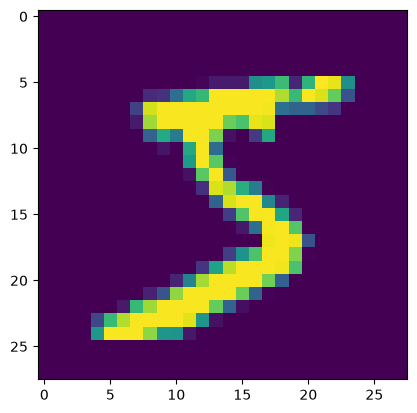

In [102]:
# display one test figure
test_fig = data_train[0]
plt.imshow(test_fig)

In [103]:
# normalize the data into the range of 0-1
data_train = data_train/data_train.max()
data_test = data_test/data_test.max()

Label = 0


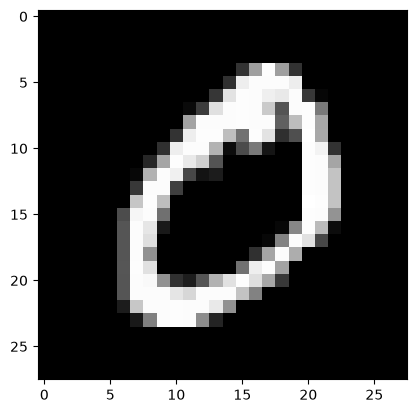

Label = 1


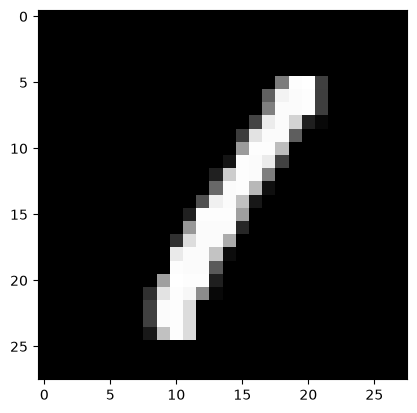

Label = 2


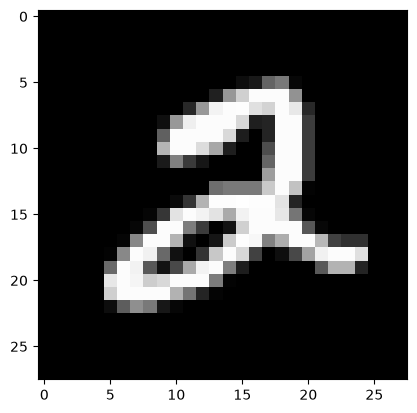

Label = 3


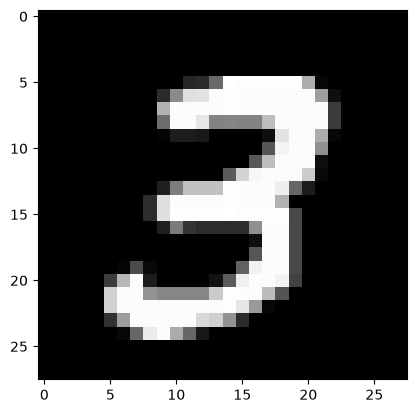

Label = 4


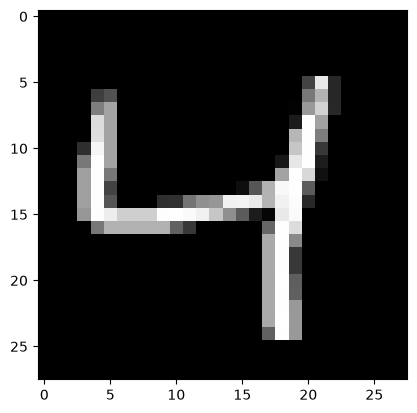

Label = 5


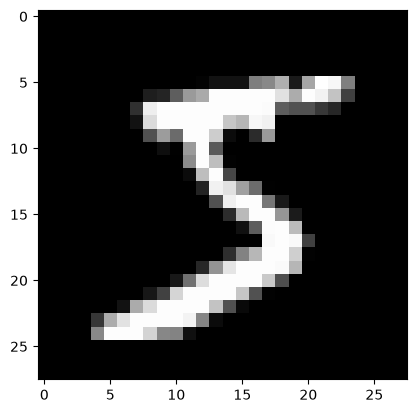

Label = 6


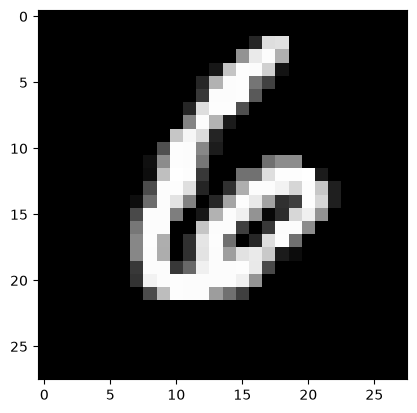

Label = 7


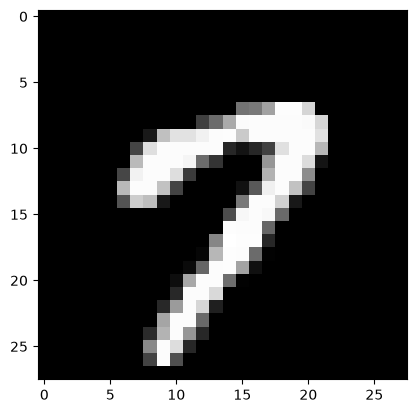

Label = 8


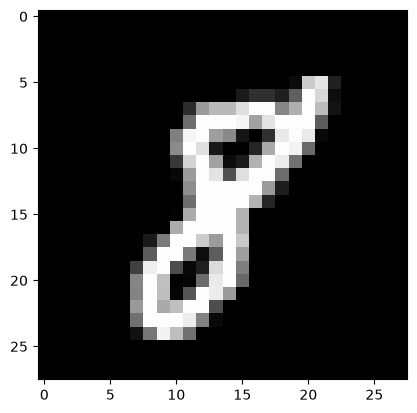

Label = 9


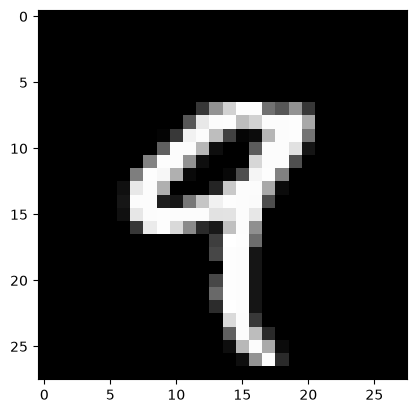

In [104]:
# display fig for each class
for i in range(10):
    for img_idx in range(10000):
        if int(label_train[img_idx]) == i:
            print('Label =', i)
            plt.imshow(data_train[img_idx],cmap = 'gray')
            plt.show()
            break
    

In [105]:
# 32 Floating Point data type is used
mem_fig = 28 * 28 * 4 / 1024  # 784 pixels × 4 bytes (float32), converted to KB
print('The required memory useage for each figure is:{} kb' .format(mem_fig) )

The required memory useage for each figure is:3.0625 kb


# Construct the MLP

In [106]:
# Considerations: number of layers, number of neurons in each layer, activation function

In [107]:
# Build up the MLP
# later you can change the number of neurons and layers

input_layer = Input(shape= data_train[0].shape)
input_layer_f = Flatten()(input_layer)

hidden_layer_1     = Dense(5, name='dense_1')(input_layer_f)
hidden_layer_1_act = Activation("relu", name="act_1")(hidden_layer_1)

hidden_layer_2     = Dense(8, name='dense_2')(hidden_layer_1_act)
hidden_layer_2_act = Activation("relu", name="act_2")(hidden_layer_2)

hidden_layer_3     = Dense(8, name='dense_3')(hidden_layer_2_act)
hidden_layer_3_act = Activation("relu", name="act_3")(hidden_layer_3)

output_layer       = Dense(10, name='output_layer')(hidden_layer_3_act)
output_layer_act   = Activation("softmax", name="softmax")(output_layer)

model = Model(input_layer, output_layer_act)


In [108]:
parameter_by_layer = np.zeros([4])

# layer 1: Dense(5) with 784 inputs → 784*5 weights + 5 biases
parameter_by_layer[0] = 784 * 5 + 5
# layer 2: Dense(8) with 5 inputs → 5*8 weights + 8 biases
parameter_by_layer[1] = 5 * 8 + 8
# layer 3: Dense(8) with 8 inputs → 8*8 weights + 8 biases
parameter_by_layer[2] = 8 * 8 + 8
# layer 4: Dense(10) with 8 inputs → 8*10 weights + 10 biases
parameter_by_layer[3] = 8 * 10 + 10

mem_model = parameter_by_layer.sum() * 4 / 1024  # 4 bytes per float32, convert to KB

print('The total memory usage for weights and bias is {} kb' .format(mem_model))

The total memory usage for weights and bias is 16.15234375 kb


In [109]:
# check the parameter numbers
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         3,925 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (Activation)              │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_3 (Activation)              │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,135 (16.15 KB)

 Trainable params: 4,135 (16.15 KB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [110]:
# compile model
# define optimizer to perform backpropagation, loss function to evaluate loss
print(tf.config.list_physical_devices())

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [111]:
# train model with 80% data for training and 20% for validation with specified number of epochs, a small number is recommended (10)
r= model.fit(data_train, label_train,  validation_split= 0.2, epochs=10)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7394 - loss: 0.8219 - val_accuracy: 0.8516 - val_loss: 0.5033
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8676 - loss: 0.4717 - val_accuracy: 0.8820 - val_loss: 0.4118
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8814 - loss: 0.4202 - val_accuracy: 0.8874 - val_loss: 0.3897
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8890 - loss: 0.3912 - val_accuracy: 0.8971 - val_loss: 0.3613
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8950 - loss: 0.3730 - val_accuracy: 0.8887 - val_loss: 0.3730
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8972 - loss: 0.3608 - val_accuracy: 0.8975 - val_loss: 0.3479
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8999 - loss: 0.3512 - val_accuracy: 0.9020 - val_loss: 0.3329
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9001 - loss: 0.3456 - 

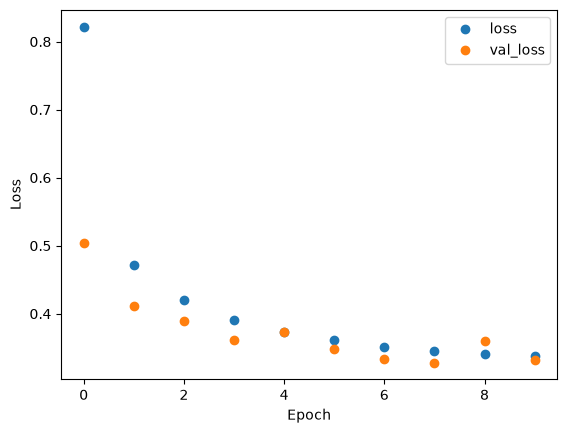

In [112]:
# plot loss
plt.plot(r.history['loss'],  'o', label='loss')
plt.plot(r.history['val_loss'],'o', label='val_loss',)
plt.ylabel('Loss')  # Set the label for the y-axis
plt.xlabel('Epoch')  # Set the label for the x-axis
plt.legend()
plt.show()

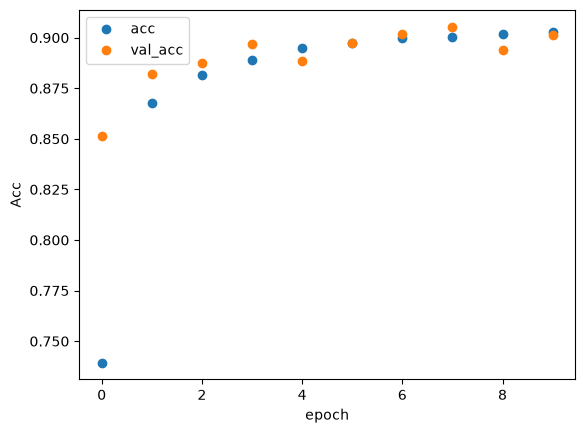

In [113]:
# Plot accuracy
acc_key     = 'accuracy'     if 'accuracy'     in r.history else 'acc'
val_acc_key = 'val_accuracy' if 'val_accuracy' in r.history else 'val_acc'
plt.plot(r.history[acc_key],     'o', label='acc')
plt.plot(r.history[val_acc_key], 'o', label='val_acc')
plt.xlabel('epoch')
plt.ylabel('Acc')
plt.legend()
plt.show()


In [114]:
# Evaluate the model with test dataset - evaluate() returns loss and accuracy
print("Train Acc", model.evaluate(data_train, label_train)[1])
acc_floatingpoint =  model.evaluate(data_test, label_test)[1]
print("Test Acc:",acc_floatingpoint )

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9026 - loss: 0.3336
Train Acc 0.9026333093643188
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8992 - loss: 0.3473
Test Acc: 0.8992000222206116


In [115]:
# save model weights
model.save_weights("weights_floatingpoint.weights.h5")

Text(0, 0.5, 'Number')

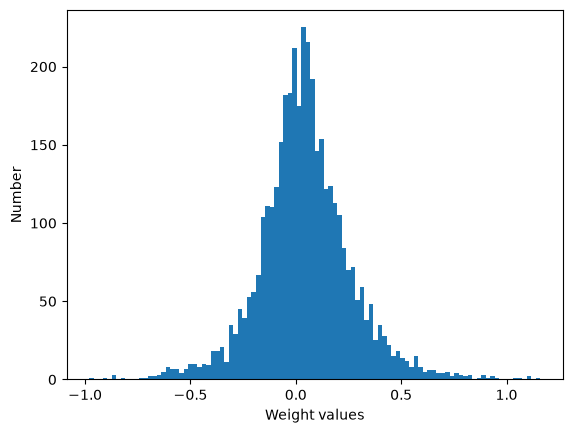

In [116]:
# observe the statistics of weights, for example in the first layer
_ = plt.hist((model.get_weights()[0].flatten()), bins = 100)
plt.xlabel('Weight values')
plt.ylabel('Number')

In [117]:
# What can you observe from the distribution of weights?

# Implement of the trained MLP with numpy

In [118]:
# implement the dense layer
def dense_layer(input_mat, input_vec, bias):
    result = np.dot(input_mat, input_vec) + bias
    return result

In [119]:
# implement the ReLU activation function
def ReLU_layer(in_activations):
    out_activations = np.zeros(in_activations.shape)
    for i in range(len(in_activations)):
        if in_activations[i] > 0:
            out_activations[i] = in_activations[i]
    return out_activations

In [120]:
# implement the softmax activation function
def softmax_layer(in_activations):
    out_activations = np.zeros(in_activations.shape)
    exp_vals = np.exp(in_activations)
    for i in range(len(in_activations)):
       out_activations[i] = exp_vals[i] / exp_vals.sum()
    return out_activations

In [121]:
# implement your own MLP, the weighs & biases should be extracted by model.get_weights()
# the softmax layer is not necessary to be implemented
weights = model.get_weights()  # [W1, b1, W2, b2, W3, b3, W4, b4]
input_example_np = np.ones([28 * 28])
output_1 = ReLU_layer(dense_layer(input_example_np, weights[0], weights[1]))
output_2 = ReLU_layer(dense_layer(output_1,        weights[2], weights[3]))
output_3 = ReLU_layer(dense_layer(output_2,        weights[4], weights[5]))
output_4 = softmax_layer(dense_layer(output_3,     weights[6], weights[7]))

In [122]:
# Display your own results
output_4

array([5.78416768e-30, 1.80039917e-31, 7.68349214e-04, 9.99231651e-01,
       1.47601260e-67, 4.62385263e-17, 2.09291056e-45, 2.33217399e-37,
       1.65501864e-17, 2.40329979e-65])

In [123]:
# Compare with the reference
model.predict(tf.ones((1, 28, 28)), steps=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


array([[5.7841052e-30, 1.8003615e-31, 7.6832558e-04, 9.9923170e-01,
        0.0000000e+00, 4.6238516e-17, 0.0000000e+00, 2.3321100e-37,
        1.6550178e-17, 0.0000000e+00]], dtype=float32)

# MLP fixed point quantization

In [124]:
# Quantized the weights and evaluate the best combination of Integer and Fractional parts
# Compare the inference acc. with TF model
# Estimate how much memory storage you can save with quantization 

In [125]:
# function to quantize weights with speficied bit width for integer and fractional part
def fixP_quantization(input_weight, int_BW, frac_BW):
    resolution_ = 2 ** (-frac_BW)           # smallest representable step
    range_       = 2 ** int_BW               # sign bit included → range is [-range_, range_)
    
    weight = deepcopy(input_weight)
    
    input_weight_clipped    = np.clip(weight, -range_, range_ - resolution_)
    input_weight_quantized  = np.round(input_weight_clipped / resolution_) * resolution_
    
    return input_weight_quantized


In [126]:
# weight_quantization — try different combinations to explore the accuracy/memory trade-off
BW_int  = 2   # integer bits (sign bit is separate)
BW_frac = 5   # fractional bits → total: 1+2+5 = 8-bit fixed point


In [127]:
weight_quantized = [deepcopy(w) for w in model.get_weights()]

In [128]:
for i in range(len(weight_quantized)):
    weight_quantized[i] = fixP_quantization(np.copy(weight_quantized[i]), BW_int, BW_frac)

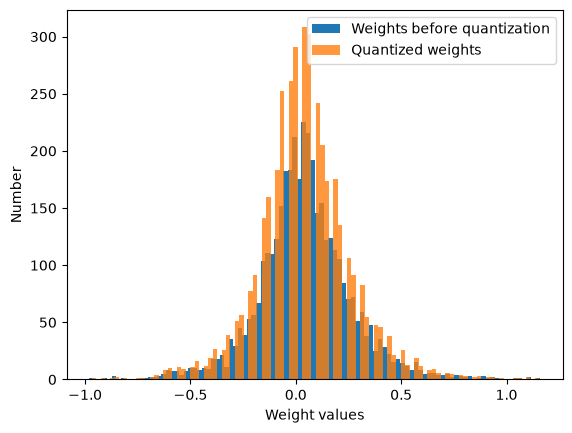

In [129]:
# plot the quantized weights in the first layer as example and compare with the floating point
_ = plt.hist((model.get_weights()[0].flatten()), bins = 100, label = 'Weights before quantization', alpha = 1)
_ = plt.hist((weight_quantized[0].flatten()), bins = 100, label = 'Quantized weights', alpha = 0.8)
plt.xlabel('Weight values')
plt.ylabel('Number')

plt.legend()

In [130]:
# define the quantized model
model_quantized = Model(input_layer, output_layer_act)

In [131]:
# load weights and save
model_quantized.set_weights(weight_quantized)
model_quantized.save_weights("weights_q_int{}_frac_{}.weights.h5".format(BW_int, BW_frac))

# Evaluation of the quantization 

In [132]:
model_quantized.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [133]:
# Evaluate the model - evaluate() returns loss and accuracy
print("Train Acc", model_quantized.evaluate(data_train, label_train)[1])
acc_quantized = model_quantized.evaluate(data_test, label_test)[1]
print("Test Acc:", acc_quantized)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8994 - loss: 0.3401
Train Acc 0.8994333148002625
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8972 - loss: 0.3538
Test Acc: 0.8971999883651733


In [134]:
# Summary
# 32 FP numbers utilized in baseline model
total_bits_quantized = 1 + BW_int + BW_frac  # sign + integer + fractional bits
saved_memory = 1 - total_bits_quantized / 32
acc_drop = acc_floatingpoint - acc_quantized

In [135]:
print("Saved memory: {}% ".format(saved_memory*100))
print("Accuracy drop: {:.2f}%" .format(acc_drop*100))

Saved memory: 75.0% 
Accuracy drop: 0.20%
